### **_Face Mask Detection_**

**_Dataset reference:_** **_https://www.kaggle.com/datasets/omkargurav/face-mask-dataset_**

#### **_Libraries_**

In [1]:
%pip install numpy matplotlib opencv-python pillow scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


#### **_Importing the Dependencies_**

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split

In [3]:
with_mask_files = os.listdir('../data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_1.jpg', 'with_mask_10.jpg', 'with_mask_100.jpg', 'with_mask_1000.jpg', 'with_mask_1001.jpg']
['with_mask_995.jpg', 'with_mask_996.jpg', 'with_mask_997.jpg', 'with_mask_998.jpg', 'with_mask_999.jpg']


In [4]:
without_mask_files = os.listdir('../data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_1.jpg', 'without_mask_10.jpg', 'without_mask_100.jpg', 'without_mask_1000.jpg', 'without_mask_1001.jpg']
['without_mask_995.jpg', 'without_mask_996.jpg', 'without_mask_997.jpg', 'without_mask_998.jpg', 'without_mask_999.jpg']


In [5]:
print(f'Number of with mask images: {len(with_mask_files)}')
print(f'Number of without mask images: {len(without_mask_files)}')

Number of with mask images: 3725
Number of without mask images: 3828


#### **_Creating Labels for the two class of Images_**
* **_With Mask - 0_**
* **_Without Mask - 1_**

In [6]:
# create the labels

with_mask_labels = [1]*3725
without_mask_labels = [0]*3828

In [7]:
print(with_mask_labels[0:5])
print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [8]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [9]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


#### **_Displaying the Images_**

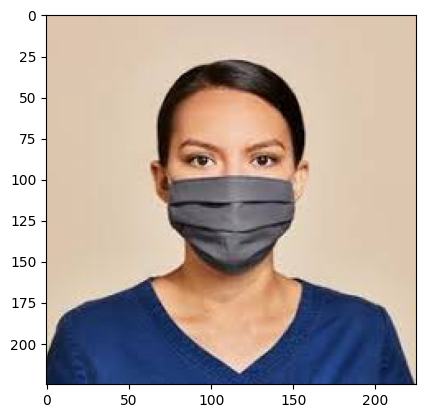

In [10]:
# displaying with mask image

img = mpimg.imread('../data/with_mask/with_mask_2429.jpg')
imgplot = plt.imshow(img)
plt.show()

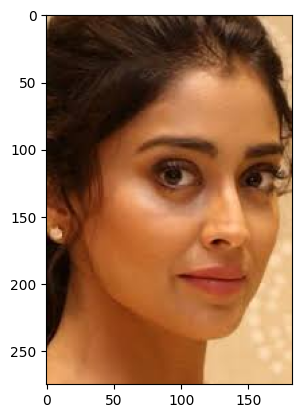

In [11]:
# displaying without mask image

img = mpimg.imread('../data/without_mask/without_mask_1770.jpg')
imgplot = plt.imshow(img)
plt.show()

#### **_Image Processing_**

1. **_Resize the Images_**

2. **_Convert the images to numpy arrays_**

In [12]:
# convert images to numpy arrays+

with_mask_path = '../data/with_mask/'
without_mask_path = '../data/without_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

c:\Users\dell\Documents\Machine Learning\ML and DL Projects\face-mask-detection\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [13]:
type(data)

list

In [14]:
len(data)

7553

In [15]:
data[0]

array([[[50, 58, 31],
        [46, 55, 33],
        [56, 58, 42],
        ...,
        [27, 32, 25],
        [29, 33, 19],
        [33, 40, 17]],

       [[47, 54, 30],
        [49, 58, 36],
        [59, 63, 40],
        ...,
        [18, 21, 11],
        [37, 42, 31],
        [31, 41, 23]],

       [[51, 58, 37],
        [50, 59, 37],
        [59, 64, 37],
        ...,
        [45, 44, 30],
        [29, 34, 27],
        [20, 30, 18]],

       ...,

       [[63, 73, 37],
        [66, 75, 41],
        [74, 84, 50],
        ...,
        [ 5,  3,  0],
        [20, 19, 14],
        [17, 16, 12]],

       [[58, 72, 34],
        [60, 70, 39],
        [68, 75, 49],
        ...,
        [16, 15, 12],
        [15, 13, 10],
        [13,  9,  7]],

       [[53, 69, 30],
        [53, 64, 37],
        [57, 64, 42],
        ...,
        [18, 18, 16],
        [16, 13, 12],
        [19, 12, 13]]], shape=(128, 128, 3), dtype=uint8)

In [16]:
type(data[0])

numpy.ndarray

In [17]:
data[0].shape

(128, 128, 3)

In [18]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [19]:
type(X)

numpy.ndarray

In [20]:
type(Y)

numpy.ndarray

In [21]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [22]:
print(Y)

[1 1 1 ... 0 0 0]


### **_Train Test Split_**

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [24]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


### **_Scaling the data_**

In [25]:
X_train_scaled = X_train/255

X_test_scaled = X_test/255

In [26]:
X_train[0]

array([[[226, 234, 201],
        [211, 216, 188],
        [188, 188, 169],
        ...,
        [186, 181, 165],
        [179, 175, 150],
        [166, 181, 136]],

       [[224, 228, 218],
        [201, 204, 195],
        [201, 199, 192],
        ...,
        [197, 190, 182],
        [175, 170, 153],
        [162, 180, 143]],

       [[205, 204, 212],
        [221, 220, 226],
        [195, 192, 196],
        ...,
        [183, 174, 173],
        [172, 167, 159],
        [181, 199, 171]],

       ...,

       [[156, 176, 197],
        [159, 180, 196],
        [164, 185, 196],
        ...,
        [ 89,  99,  71],
        [106, 113,  83],
        [ 99, 103,  68]],

       [[151, 177, 196],
        [167, 190, 208],
        [174, 192, 210],
        ...,
        [106, 113,  80],
        [ 99, 104,  64],
        [ 98,  98,  41]],

       [[162, 192, 210],
        [177, 199, 220],
        [175, 189, 213],
        ...,
        [103, 107,  70],
        [ 79,  80,  46],
        [ 99,  94,  61]]

In [27]:
X_train_scaled[0]

array([[[0.88627451, 0.91764706, 0.78823529],
        [0.82745098, 0.84705882, 0.7372549 ],
        [0.7372549 , 0.7372549 , 0.6627451 ],
        ...,
        [0.72941176, 0.70980392, 0.64705882],
        [0.70196078, 0.68627451, 0.58823529],
        [0.65098039, 0.70980392, 0.53333333]],

       [[0.87843137, 0.89411765, 0.85490196],
        [0.78823529, 0.8       , 0.76470588],
        [0.78823529, 0.78039216, 0.75294118],
        ...,
        [0.77254902, 0.74509804, 0.71372549],
        [0.68627451, 0.66666667, 0.6       ],
        [0.63529412, 0.70588235, 0.56078431]],

       [[0.80392157, 0.8       , 0.83137255],
        [0.86666667, 0.8627451 , 0.88627451],
        [0.76470588, 0.75294118, 0.76862745],
        ...,
        [0.71764706, 0.68235294, 0.67843137],
        [0.6745098 , 0.65490196, 0.62352941],
        [0.70980392, 0.78039216, 0.67058824]],

       ...,

       [[0.61176471, 0.69019608, 0.77254902],
        [0.62352941, 0.70588235, 0.76862745],
        [0.64313725, 0

### **_Building a Convolutional Neural Networks (CNN)_**

In [28]:
%pip install tensorflow --no-cache-dir

Note: you may need to restart the kernel to use updated packages.


In [29]:
import tensorflow as tf
from tensorflow import keras

**_keras.Sequential() creates a neural network model where layers are arranged in a linear stack, meaning the output of one layer becomes the input of the next layer._**

In [30]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

c:\Users\dell\Documents\Machine Learning\ML and DL Projects\face-mask-detection\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### **_Compile the neural network_**

In [31]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])

### **_Training the neural network_**

In [32]:
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=20, batch_size=32)

Epoch 1/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 93s 526ms/step - acc: 0.8146 - loss: 0.4374 - val_acc: 0.9008 - val_loss: 0.2544
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 81s 473ms/step - acc: 0.8950 - loss: 0.2699 - val_acc: 0.9240 - val_loss: 0.2241
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 86s 494ms/step - acc: 0.9130 - loss: 0.2190 - val_acc: 0.9306 - val_loss: 0.2028
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 61s 356ms/step - acc: 0.9353 - loss: 0.1727 - val_acc: 0.9388 - val_loss: 0.1905
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 54s 320ms/step - acc: 0.9415 - loss: 0.1517 - val_acc: 0.9355 - val_loss: 0.1967
Epoch 6/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 52s 304ms/step - acc: 0.9529 - loss: 0.1240 - val_acc: 0.9388 - val_loss: 0.2188
Epoch 7/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 55s 322ms/step - acc: 0.9634 - loss: 0.1017 - val_acc: 0.9488 - val_loss: 0.1998
Epoch 8/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 86s 503ms/step - acc: 0.9719 - loss: 0.0837 - val_acc: 0.9488 - val_loss: 0.2052
Epoch 9/20
170/170 ━━━━━━━━━━━━━

### **_Model Evaluation_**

In [33]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - acc: 0.9484 - loss: 0.1969
Test Accuracy = 0.9483785629272461


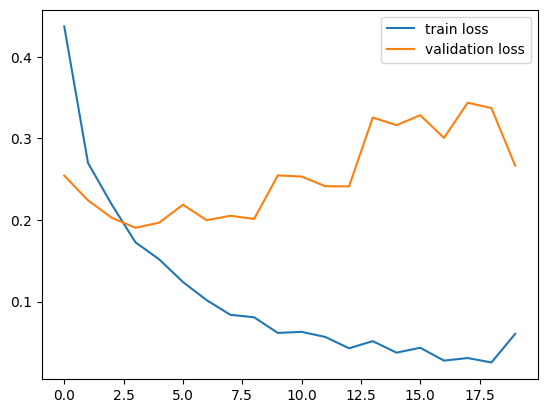

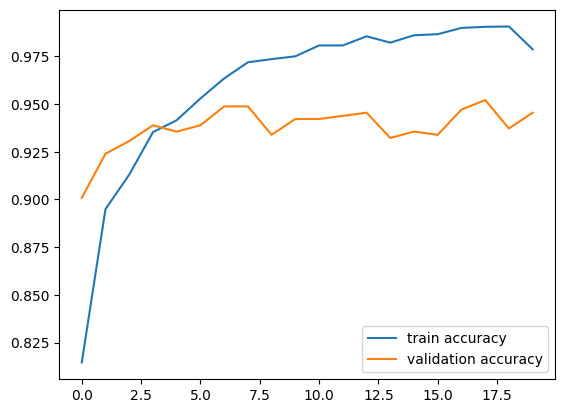

In [34]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

### **_Predictive System_**

In [35]:
def predict_mask(image_path):

    # Read Image
    input_image = cv2.imread(image_path)

    if input_image is None:
        print("Image not found")
        return

    # Convert BGR into RGB
    input_image_rgb = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)

    # Show Image
    plt.imshow(input_image_rgb)
    plt.title("Input Image")
    plt.axis('off')
    plt.show()

    # Preprocessing
    resized = cv2.resize(input_image_rgb, (128, 128))
    scaled = resized / 255.0

    # Add batch dimension
    reshaped = np.expand_dims(scaled, axis=0)

    prediction = model.predict(reshaped)
    print("Raw Prediction:", prediction)

    probability = prediction[0][0]

    if probability > 0.5:
        print("Person is Wearing Mask")
    else:
        print("Person is NOT Wearing Mask..!")

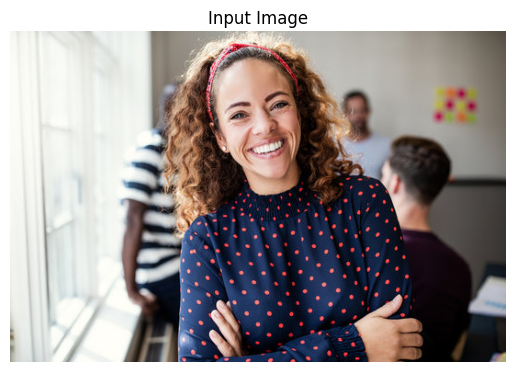

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
Raw Prediction: [[0.01545484 0.99915457]]
Person is NOT Wearing Mask..!


In [36]:
input_image_path = input("Enter Image Path: ")

predict_mask(input_image_path)

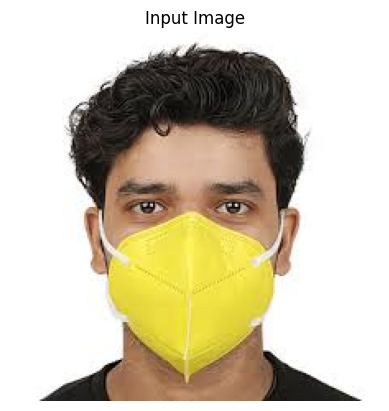

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Raw Prediction: [[0.6685946 0.5197862]]
Person is Wearing Mask


In [37]:
input_image_path = input("Enter Image Path: ")

predict_mask(input_image_path)